# Warrior Scholar Program: Data Exploration Lab
**Your goal this week: Learn how to explore datasets, and how to use data and statistics to ask and answer questions!**

Data science is a rapidly growing interdisciplinary STEM field that focuses on extracting information and actionable insights from data. Data science applies the scientific method and a variety of techniques, such as statistical and graphical analysis, to answer questions such as “What is happening, and why?” Today, datasets of unprecedented size, quality, and variety are becoming increasingly available, and the techniques to explore and analyze them are quickly advancing as well. As a result, we are seeing more examples of data-driven content around us, from the news cycle to advertising to politics and policies.

We are all affected by the results of data analysis, and it is therefore helpful to understand how datasets are analyzed, how to ask and then answer questions with data, and how cautious we should be when interpreting the results. In this lab, you will learn to use the Python programming language to perform exploratory data analysis on two different datasets. You will learn how to define questions that can be answered with a given dataset, the various descriptive statistical techniques needed to answer such questions, and how to visualize and characterize your results.

---

This week you will:

1. Get started with Python! As a recap/continuation of the Python Primer you went through on Sunday, we'll go through an additional **tutorial** together to help strengthen the foundations for the rest of the week.

2. Work through a **guided project** investigating a dataset containing information about penguins.

3. Work together to design and carry out an **independent project** using data collected from FitBits!

---

# 2) Exploratory data analysis

An exploratory data analysis allows us to summarize -- and visualize! -- the main characteristics or properties within a dataset. In data science, this is one of the first steps, and is crucial to perform before moving on to building models, making quantitative predictions, etc. The goal is to gain insights from data -- and the key word is _"explore"_! We don't know what we'll find in a dataset (or what questions we can ask) until we poke around and get a sense for what things look like.  In other words, we need to understand our dataset before we can learn from it.

Performing an exploratory data analysis is how we determine the best way to use a dataset and what it can tell us. Let's try it out!

## Part 1: Asking questions and drawing insights from data: Guided analysis with the Penguins dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading and viewing datasets

For the first part of our exploratory data analysis lab, we will use a dataset describing the physical characteristics of various species of penguins.

Let's load in the data!

In [2]:
penguins = pd.read_csv("penguins.csv")

This dataset consists of seven columns, whose descriptions can be found below:

``` 
species: Penguin species

island: Islands where they are found

bill_length_mm: Bill length in mm

bill_depth_mm: Bill width in mm

flipper_length_mm: Flipper length in mm

body_mass_kg: Mass of Penguins

sex: Sex of Penguins
```

---

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80"> What kinds of questions do you think could be asked and/or answered using this dataset? 

What kinds of questions can we _not_ address with these data? (What information is missing?)

---

For a preview of the contents, simply run the following cell:

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_kg,sex
0,Adelie,Torgersen,39.1,18.7,181,3.750,male
1,Adelie,Torgersen,39.5,17.4,186,3.751,female
2,Adelie,Torgersen,40.3,18.0,196,3.752,female
3,Adelie,Torgersen,36.7,19.3,193,3.753,female
4,Adelie,Torgersen,39.3,20.6,190,3.754,male
...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207,4.078,male
329,Chinstrap,Dream,43.5,18.1,202,4.079,female
330,Chinstrap,Dream,49.6,18.2,193,4.080,male
331,Chinstrap,Dream,50.8,19.0,210,4.081,male


As we can see from the output of the cell above, the `penguins` dataset is actually a _table_ of data, with rows and columns. (In this case, 333 rows and 7 columns.)

Every row is a different entry (i.e., a different penguin), and the different columns contain various physical properties.

This is a **Pandas Dataframe.** Pandas is another python library that is designed specifically to help us work with datasets. We'll go over a quick tutorial together now -- you may notice some similarities with dictionaries!

--- 

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80"> Let's take a few minutes to go over the **Pandas DataFrames tutorial** as a group.

---

In the cell below, print out the names of every column in the penguins dataframe, as follows:

``` python
# view the column names in the penguins dataframe:
penguins.columns
```



Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_kg', 'sex'],
      dtype='object')

Now let's take a look at the indices of the dataframe. As we saw in the tutorial, the index is just the order that the rows appear in the table - it begins at `0` and then counts up from there. 

In the cell below, print out the indices to take a closer look:

``` python
# view the indices of the penguins dataframe
penguins.index
```

Another way to quickly view the contents of this database is to use the `.head()` function.

Type the following into the cell below, and see what happens:


```python
# view the header
penguins.head()
```



As we saw in the tutorial, if we want to view the "species" column in the penguins dataframe, we can do the following:


``` python
# direct access
penguins['species']

# access by "location"
penguins.loc[:,"species"]

# access by "index location"
penguins.iloc[:,0]
```

Which of these do you prefer? Why?

Choose your favorite, and use the cell below to print out the contents of the "species" column.

Print out the values of the `body_mass_kg` column:

We can use `np.unique()` to get all the unique elements of a column. Find the unique elements of the the species column:

Recall that we can view a *subset* of the dataframe using conditional statements. 

For example, in the tutorial, we looked at the "species" column for the subset of rows (penguins) that live on the Torgersen island:
``` python
# access by "location"
penguins.loc[penguins["island"]=="Torgersen","species"]
```


In the cell below, print out the "island" column for penguins belonging to the Chinstrap species:

### Types of questions we can ask

One of the most challenging parts of any project is deciding which direction to go in: which questions to ask, which plots to make, which analysis to do, etc. 

---

In this lab we'll practice asking questions and attemping to answer them using our data!

Broadly speaking, we'll cover **two types of questions:**  
1. Questions that ask for a description or summary of the data, and
2. Questions that ask how different properties within a dataset relate to one another.

---

For the **first type**, these might be things like:  
*   What are typical values of a particular property?
*   What is the spread in the data? (or: How "clumpy" are the data?)

For the **second type**, these might be things like:  
*   If I know one property, how well do I know (or can guess) another?
*   Can I explain the spread or shape of one property's distribution with other properties?

---


### Descriptive statistics: what do the data look like?




Descriptive statistics are often used as part of an exploratory data analysis, because they allow us to characterize and summarize our data.



When dealing with a **single, individual** property within a dataset (for example, the flipper length), our goal is generally to describe:

1.   The _central tendancy_ of the distribution (in other words, the value that the data seems to cluster around)
2.   The _dispersion_ of the distribution (the degree to which the data are stretched or squeezed around this central value)


Let's explore some useful measures now.

#### Viewing a distribution: histograms

But first -- what if we want to _look at_ our data?

The simplest way to display and summarize any individual property (column) in the dataset is to create a **histogram**.

A **histogram** is a plot that shows us how frequently different values occur in a dataset. For example, let's say we ask everyone in WSP what month they were born in. It will probably turn out that some months are more common than others. Maybe 5 people were born in July, 3 in October, 4, in September, 1 in January, and so on. 

If we were to visualize this, we would have each month on the x-axis and the *number of students born that month* on the y-axis. In other words, looking at a histogram lets us quickly see which months occur more often than others.

In this example, each month represents what's called a **"bin"** -- in other words, it's a range of values (think of an interval or a "bucket") that we'll divide the data into. Think about what a month is: a collection of dates! We don't care whether someone was born on April 1 or April 30 -- anyone born on any day in April is going into the April bin.

(Note: we could have decided to have each day of the year be its own bin! But in this case we'll focus on months since they're easier to visualize.)

Text(0, 0.5, 'Number of students born per month')

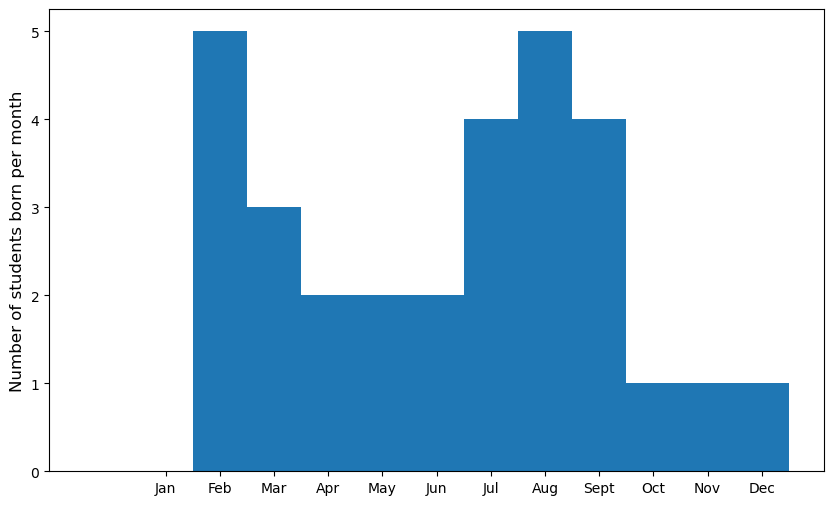

In [ ]:
# randomly generate student birth months
months = np.random.randint(1, 13, 30)

# display histogram
plt.figure(figsize = (10, 6))
plt.hist(months, bins = range(0, 14), align = 'left')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Number of students born per month', fontsize = 'large')

Getting back to our penguins dataset, we can use the histogram to see, for example, which flipper lengths are more commonly occuring than others.

In this case, the **bins** we'll use will be ranges of flipper lengths. For instance, if flippers run from 170 to 230 mm, we might set our bins to go from 170-175, 175-180, 180-185, and so on.

The more bins we have, the narrower they'll be! (If our bins are 5 mm wide we'll need 13 of them, but if they are only 1 mm wide we'll need 61 to cover the same range in flipper lengths!)

We can use `plt.hist()` to create a histogram of our penguin flipper data. We can save our figure using `plt.savefig()`.

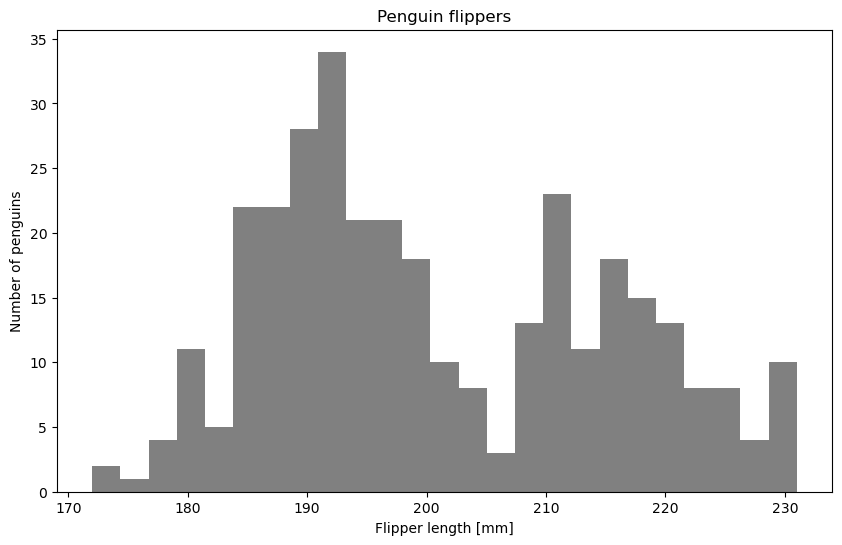

In [17]:
plt.figure(figsize = (10, 6))

plt.hist(penguins["flipper_length_mm"], bins = 25, color = "grey")

plt.xlabel('Flipper length [mm]')
plt.ylabel('Number of penguins')
plt.title('Penguin flippers')

plt.savefig('histogram_flipper_length_mm.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How would you describe the distribution of penguin flipper lengths? 

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  What happens to the shape of this distribution if you change the histogram bin size? Try setting `num_bins = 5, 10, 25, 50, 100` in the cell below:

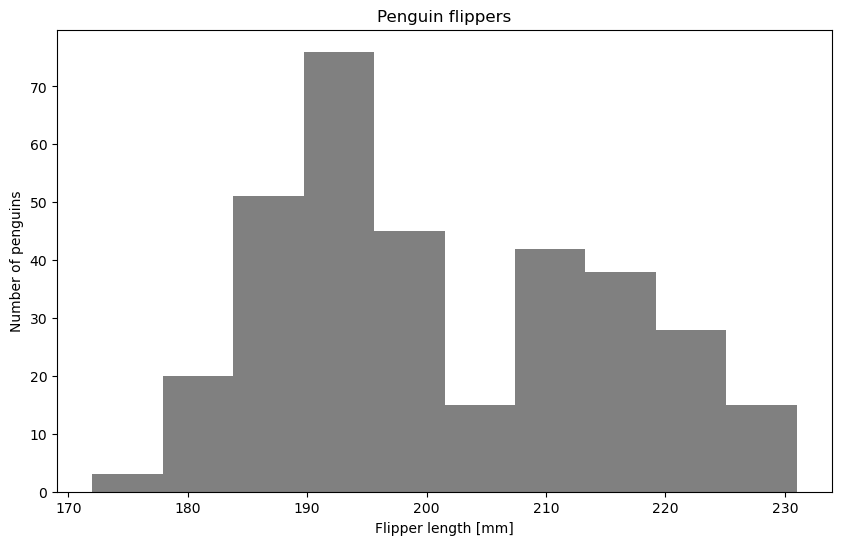

In [18]:
num_bins = 10 # change number of bins here!

# create histogram
plt.figure(figsize = (10, 6))

plt.hist(penguins["flipper_length_mm"], bins = num_bins, color = "grey")

plt.xlabel('Flipper length [mm]')
plt.ylabel('Number of penguins')
plt.title('Penguin flippers')

plt.savefig('histogram_flipper_length_mm.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80">   Play around with the appearance of your histogram! 

Try changing the X and Y axis labels, the title, the fontsizes, the color, etc. 

You can find a list of color names that python recognizes [here](https://matplotlib.org/3.1.0/gallery/color/named_colors.html).

You can find information about the parameters to change the style of the `plt.hist` [here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

You can change the size of the x, y, and title labels using the `fontsize` parameter.

In [ ]:
# create histogram
plt.figure(figsize = (10, 6)) # change figure size here!

plt.hist(penguins["flipper_length_mm"], bins = 25, color = "grey")

plt.xlabel('Flipper length [mm]', fontsize = 12)
plt.ylabel('Number of penguins')
plt.title('Penguin flippers')

plt.savefig('histogram_flipper_length_mm.png')

#### "Typical" values of a distribution

##### Mean value

A common way to estimate the central value of a distribution is to calculate the mean (average) value.

The mean of a distribution is calculated by summing up all the values, and then dividing by the number of values. However, once again we have help from built-in functions! We can quickly calculate the mean flipper length using the Pandas `mean` function.

In the cell below, type the following to find the average flipper length:

```python 
penguins['flipper_length_mm'].mean()
```



##### Median value

Another measure of the central value of the distribution is the _median value_. 

The median of the distribution is just the middle value! You could find it by hand if you were to sort the data (increasing or decreasing order) and then find the value that is halfway through the list. However, it's faster to use the Pandas `median` function.

In the cell below, type the following to find the median flipper length:

```python 
penguins['flipper_length_mm'].median()
```

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How does the median value compare to the mean value of the distribution? 

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Look back at the histogram to see the full distribution. In this case, which measurement (mean vs median) would you choose to describe the typical flipper length? Why?

#### Spread (width) of a distribution

Often it's useful to know how broad a distribution is. Is a dataset well described by its "typical" value or not? 

For example, compare the plots below:

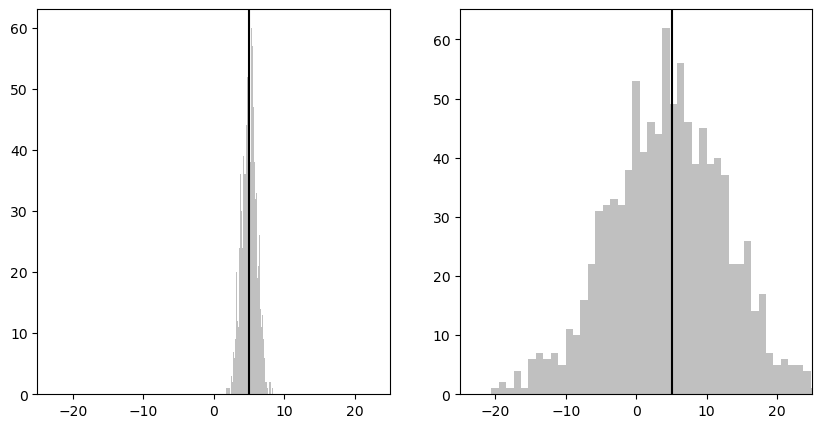

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# distribution 1
axes[0].hist(np.random.normal(loc=5, scale=1.0, size=1000), bins=50, color='silver')
axes[0].axvline(5, color='k')
axes[0].set_xlim(-25, 25)

# distribution 2
axes[1].hist(np.random.normal(loc=5, scale=8.0, size=1000), bins=50, color='silver')
axes[1].axvline(5, color='k')
axes[1].set_xlim(-25, 25);

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How well is each distribution described by its mean value?

##### Minimum and Maximum values

To start with, we might want to know the full range of values that a property can take. What is the smallest (minimum) value, and what is the largest (maximum)?

We can use the Pandas `min` and `max` functions to find out.

In the cell below, type the following to determine the smallest flipper length:

```python
penguins['flipper_length_mm'].min()
```



In the cell below, find the longest flipper length (hint: swap out `.min()` for `.max()` in the previous call.

What if we wanted to find the smallest flipper length for Adelie penguins? 

Recall that we can view a *subset* of the dataframe using conditional statements. 

For example, in the tutorial, we looked at the "species" column for the subset of rows (penguins) that live on the Torgersen island:
``` python
# access by "location"
penguins.loc[penguins["island"]=="Torgersen","species"]
```


In the cell below, print out the minimum value (using `.min()`) of the "flipper_length_mm" column for penguins belonging to the Adelie species:

##### Standard deviation

Next, we might wonder how tightly the data cluster around the mean of a distribution. Are most points pretty close the the average? Or is there a wider spread? 

One way to do this is to calculate the _standard deviation_ of the distribution (https://en.wikipedia.org/wiki/Standard_deviation). This is a way of quantifying how far away the individual data points typically are from the mean. The lower the value of the standard deviation, the more tightly clustered the data are around the central value.

As an extreme example, if the standard deviation were *zero* that would imply that every single data point is exactly the same (and equal to the mean value)

We can use the Pandas `std` function to calculate the standard deviation of penguin flipper lenghts.

In the cell below, type the following:

```python 
penguins['flipper_length_mm'].std()
```

To help understand what the mean and standard deviation are, let's revist our histogram, but this time we'll also plot the position of the mean as well as the boundaries imposed by the standard deviation:

In [ ]:
mean_flipper_length =  # find mean flipper length here
std_flipper_length =   # find standard deviation of flipper length here

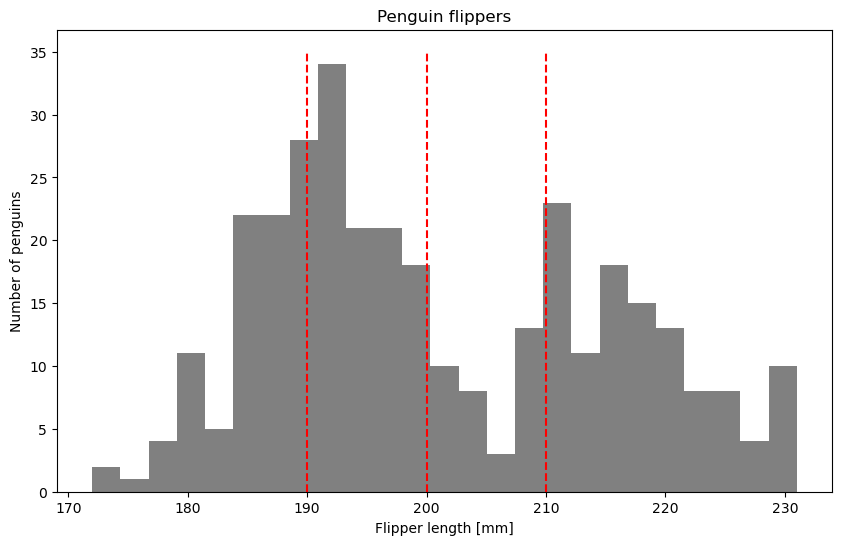

In [32]:
# create histogram
plt.figure(figsize = (10, 6)) # change figure size here!

plt.hist(penguins["flipper_length_mm"], bins = 25, color = "grey") # plot histogram
plt.vlines(mean_flipper_length, 0, 35, color = "red", linestyle = "--") # plot mean line
plt.vlines(mean_flipper_length - std_flipper_length, 0, 35, color = "red", linestyle = "--") # plot one stdev below
plt.vlines(mean_flipper_length + std_flipper_length, 0, 35, color = "red", linestyle = "--") # plot one stdev above

plt.xlabel('Flipper length [mm]')
plt.ylabel('Number of penguins')
plt.title('Penguin flippers')

plt.savefig('histogram_flipper_length_mm.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80">  We can also use the standard deviation to identify outliers. For example, if a penguin has a flipper length of 210 mm, we can see from the histogram that this is less than 1 standard deviation away from the mean -- so it's fair to call this a typical or expected value.

On the other hand, if we measured a penguin flipper length of 340 mm, that would be 10 standard deviations away from the mean! (Remember that the mean was about 200 mm and the standard deviation about 14 mm.) In other words, a flipper length of 340 mm would be a *very* unexpected or unusual value.

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How well do you think the distribution of flipper lengths are described by the mean and standard deviation? 

Think about: do the data really appear to be clustered around the mean?

##### Percentiles

A slightly more robust way of characterizing the degree to which our data are spread or squeezed around the central value is to calculate the _percentiles_ (https://en.wikipedia.org/wiki/Percentile). 

Percentiles describe the value below which some percentage of the distribution falls.

For example, if you take an exam and are in the 80$^{\rm th}$ percentile, this means that 80 percent of the people who took this test scored _lower_ than you did.


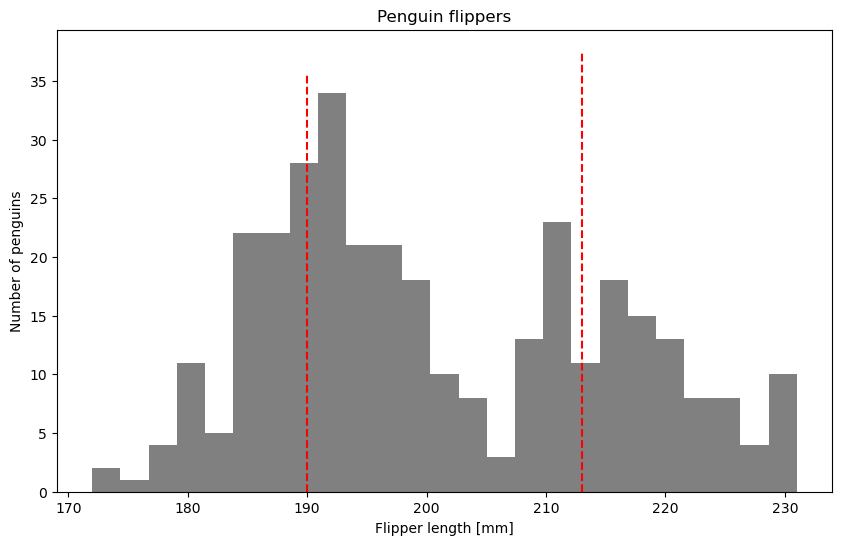

In [ ]:
percentile_25 = penguins["flipper_length_mm"].quantile(0.25)
percentile_50 = # find 50th percentile of flipper length here
percentile_75 = # find 75th percentile of flipper length here

# create histogram
plt.figure(figsize = (10, 6)) # change figure size here!

plt.hist(penguins["flipper_length_mm"], bins = 25, color = "grey") # plot histogram
plt.vlines(percentile_25, 0, 40, color = "red", linestyle = "--")  # plot 25th percentile line
plt.vlines(percentile_50, 0, 40, color = "red", linestyle = "--")  # plot 25th percentile line
plt.vlines(percentile_75, 0, 40, color = "red", linestyle = "--")  # plot 75th percentile line

plt.xlabel('Flipper length [mm]')
plt.ylabel('Number of penguins')
plt.title('Penguin flippers')

plt.savefig('histogram_flipper_length_mm.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Looking at the plot above: half of all flippers in this dataset are smaller than what value? 

What is the relationship between the 50th percentile and the median value of a distribution?

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  75 percent of flippers are smaller than what value?

25 percent of flippers are smaller than what value?

Describe the "middle 50 percent" of this distribution, or the **"interquartile range"**. (In other words: half of the flippers lie between which two values?)

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80"> What do we gain by calculating percentiles instead of (or in addition to) the mean and standard deviation?

Now add the 10th and 90th percentiles to your plot above!

#### Summarizing

Pandas has a helpful function, `describe`, to help us quickly calculate all of the measures we've just looked at. 

In the cell below, try running

``` python
penguins.describe()
```



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_kg
count,333.000000,333.000000,333.00000,333.000000
mean,43.992793,17.164865,200.96997,3.916000
std,5.468668,1.969235,14.01459,0.096273
min,32.100000,13.100000,172.00000,3.750000
25%,39.500000,15.600000,190.00000,3.833000
50%,44.500000,17.300000,197.00000,3.916000
75%,48.600000,18.700000,213.00000,3.999000
max,59.600000,21.500000,231.00000,4.082000


Notice that only the quantitative penguin properties (length, depth, mass) are shown here.  The other properties (sex, island, species) are categorical, and represented as strings (text) rather than numbers -- so we cannot calculate the same statistics for them. 

We can limit the output of `describe` to a single property, like this:


``` python
penguins['bill_length_mm'].describe()
```

Try it in the cell below:


Finally, we can also specify which percentiles to show! The defaults are `20%, 50% and 75%`, but we can change these using the optional `percentiles` argument.

Type the following into the cell below:

```python
penguins['bill_length_mm'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
```



##### Quantitative vs Categorical data

Datasets can be quantitative (i.e., comprised of numbers) or categorical ("type A", "type B", etc). 

Let's look again at the contents of our dataset:

In [ ]:
penguins.head()

Fill in the two lists below. 

The name of each *quantitative* property in the dataset should go in the `quantitative_properties` list, and the name of each *categorical* property should go in the `categorical_properties` list. 

An example of each kind is filled in for you below. Fill in the rest! (Every property in the dataset should go into one of the lists)

In [ ]:
quantitative_properties = []
categorical_properties = []

So far, we've been exploring different statistical measures by looking at bill length, which is a quantitative property. 

Let's quickly take a look at the distributions for the others! We can use a `for loop` to accomplish this:

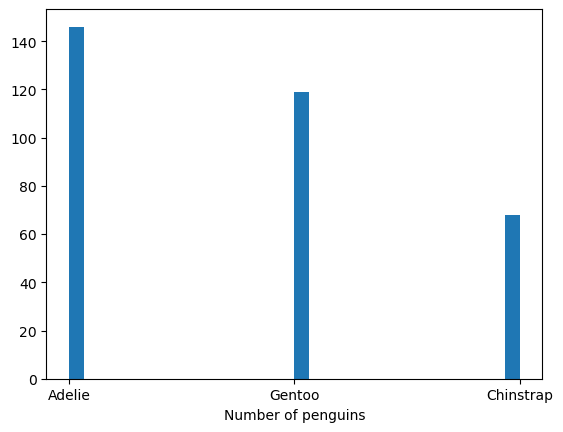

In [ ]:
for quant_prop in quantitative_properties:
  plt.hist(penguins[quant_prop], bins = 30)
  plt.ylabel('Number of penguins')
  plt.show()
  plt.savefig('percentiles_%s.png' % quant_prop)

As we saw earlier, we can't calculate summary statistics for our categorical properties in the same way that we do for our quantitative properties.

However, we can make histograms:

In [ ]:
for cat_prop in categorical_properties:
  plt.hist(penguins[cat_prop], bins = 30)
  plt.ylabel('Number of penguins')
  plt.show()
  plt.savefig('percentiles_%s.png' % cat_prop)

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How well do you feel you understand this dataset from the histograms and summary statistics alone?

Why might it be a good idea to create plots like this at the start of any data science project? 

#### Example Qs

So, what kinds of questions can we ask (and answer) using descriptive statistics? Let's look at a couple examples!

##### Q1: Bill length

**Question:** How long are penguin bills typically? 

**Strategy:** We will measure the mean or median penguin bill length (or both!)

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">

**Question:** It's unlikely that every penguin has exactly the same bill length. So, how much do bill lengths *vary* within the sample?

**Strategy:** Think back to the methods we learned for estimating how much variation there is in a property (i.e., what is the spread in the distribution). Pick your favorite strategy and try it out! 

Why did you pick the method you did? 

##### Q2: Flipper length

**Question:** How long can a penguin's flippers be?

**Strategy:** We want to find the longest flipper length in the sample! We can use the `.max()` function in pandas to do this:

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">

**Question:** How much variation do we see in flipper length within this sample? Is the distribution of flipper lengths approximately symmetric? 

**Strategy:** Think about methods we learned for estimating the width and symmetry in a distribution! What do you want to try here, and why?

### How are different properties/features within the dataset related?

While looking at one property at a time can be a super useful way to get started, we don't need to stop here! It's often extremely helpful to make a _scatter plot_ to examine the relationship between two or more different properties. 

#### Scatter plots



Another great plot to make is the **scatter plot**! This is a way of comparing two different properties within a given dataset -- one will go on the x-axis, and the other on the y-axis. Each point on the plot represents a single datapoint (in our case, a single penguin).

We make **scatter plots** to examine relationships between the different properties (if any exist).

To see this more clearly, let's jump in and start by plotting the bill length against bill depth.

The x-axis shows us the values of penguin bill lengths, while the y-axis shows the values of penguin bill depths. Remember that each data point represents an individual penguin!

Text(0, 0.5, 'Bill depth [mm]')

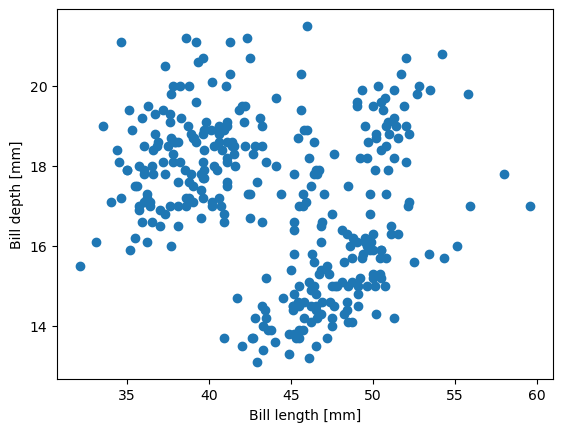

In [ ]:
plt.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"])
plt.xlabel('Bill length [mm]')
plt.ylabel('Bill depth [mm]')

plt.savefig('bill_length_depth.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80">  Play around with the appearance of your scatter plot! 

Try changing the color of the symbols via the `color` input, and the size of the symbols via the `s` input.

In [ ]:
plt.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"])
plt.xlabel('Bill length [mm]')
plt.ylabel('Bill depth [mm]')

plt.savefig('bill_length_mm_bill_depth_mm.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Aside from wanting to make nice-looking plots, can you think of some benefits to customizing the colors and sizes of datapoints? 

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80">  Try plotting different combinations of properties! You can print all the columns of the dataframe using `penguins.columns`

In [ ]:
plt.scatter(penguins["bill_length_mm"], penguins["bill_depth_mm"])
plt.xlabel('Bill length [mm]')
plt.ylabel('Bill depth [mm]')

plt.savefig('bill_length_mm_bill_depth_mm.png')

#### Pair grids

Sometimes we want to plot "everything vs everything", because this allows us to efficiently identify which relations exist and are worth exploring further. 

A [pair grid](https://seaborn.pydata.org/generated/seaborn.pairplot.html#seaborn.pairplot) will let us do just that! There's a convenient library in python called [seaborn](http://seaborn.pydata.org/examples/index.html) that lets us make a bunch of different useful and nice-looking plots. We imported this already (with the alias `sns`) in the "Get started" cell earlier.

In [ ]:
import seaborn as sns

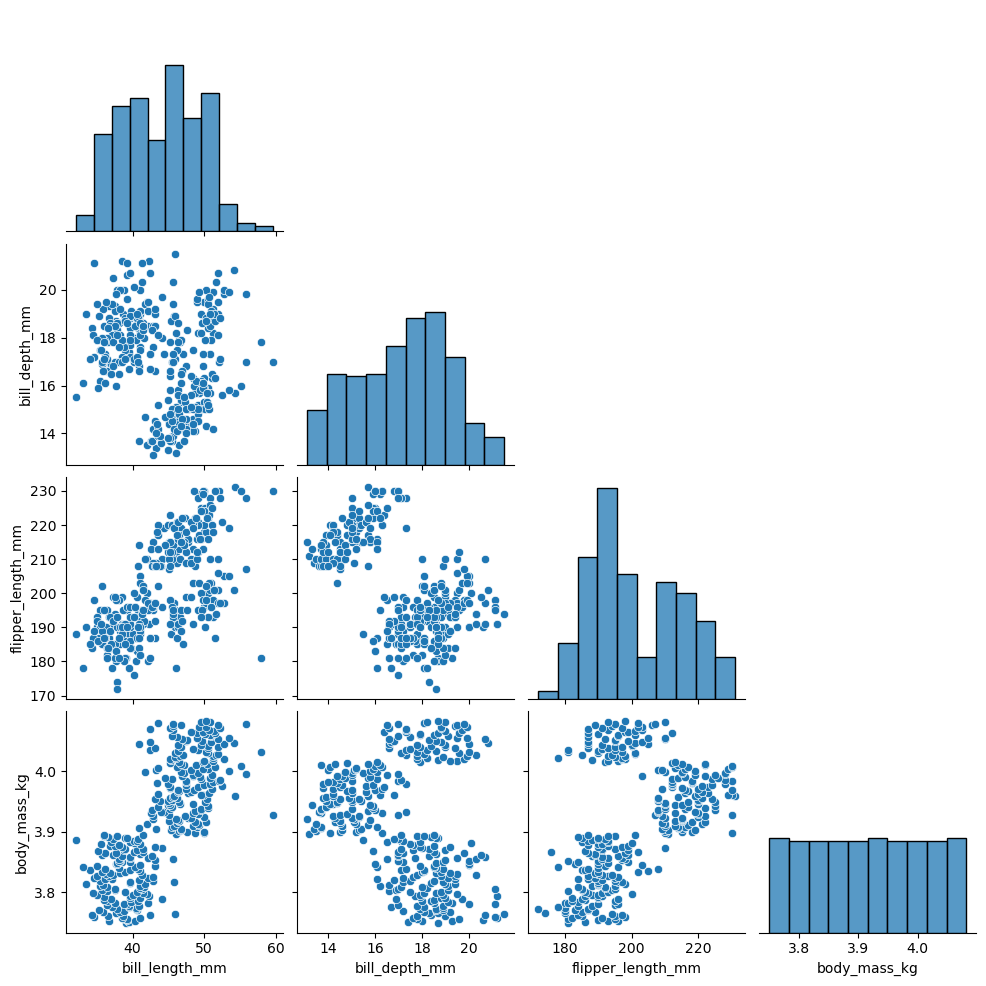

In [ ]:
sns.pairplot(penguins, corner = True)

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80"> Take a minute or two and stare at this pair grid.

Each set of axes plots one property vs another property, and we have every combination of **quantitative** properties displayed. 

The **diagonal** plots show histograms of the property on the x-axis.

---

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80"> What do you think? Which relationships are most interesting to you?

What questions do you have about the data? Are you curious about anything here?

---

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Now that we've looked at some of the relationships between different properties, how well do you feel you understand this dataset?

Why might it be a good idea to look into relationships within the data early on in a data science project?

---

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  What additional questions about the dataset come to mind at this point? 

---

#### Example Qs

Similar to what we did above, let's run through a couple examples of questions that involve comparing two or more properties within the dataset!

##### Q1: Flipper length

**Question:** Which species has the longest flipper length?

**Strategy:** Let's group our penguins dataset by `species`, and then calculate the mean flipper length within each group.

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">

**Question:** Do male and female penguins have similar length flippers?

**Strategy:** Think about methods we learned for estimating typical values of a distribution, and how we can group data. What do you want to try here, and why?

##### Q2: Bill shape

**Question:** Do male and female penguins have the same bill shape?

**Strategy:** Make a scatterplot of `bill_depth_mm` and `bill_length_mm`, and use the `color_property` parameter to color the data points by the sex of the penuins:

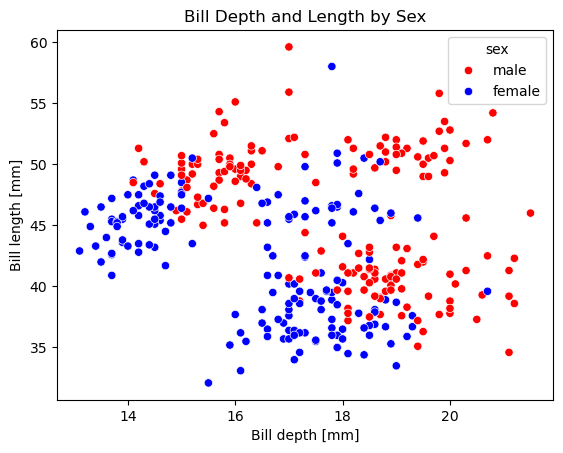

In [ ]:
sns.scatterplot(data = penguins, x = "bill_depth_mm", y = "bill_length_mm", hue = "sex") # you can change the colors using palette = ["red", "blue"], for example
plt.xlabel('Bill depth [mm]')
plt.ylabel('Bill length [mm]')
plt.title('Bill Depth and Length by Sex')

plt.savefig('bill_depth_bill_length_colorby_sex.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Based on the scatter plot we just made, do male and female penguins have the same bill shapes? If not, how are they different? 

Feel free to color the points by other values as well if you are curious!

We can add a layer of complexity by also changing the _size_ of the data points!

Update your scatter plot so that the size of the points scales with flipper length. Use the `size_property` parameter to do this:

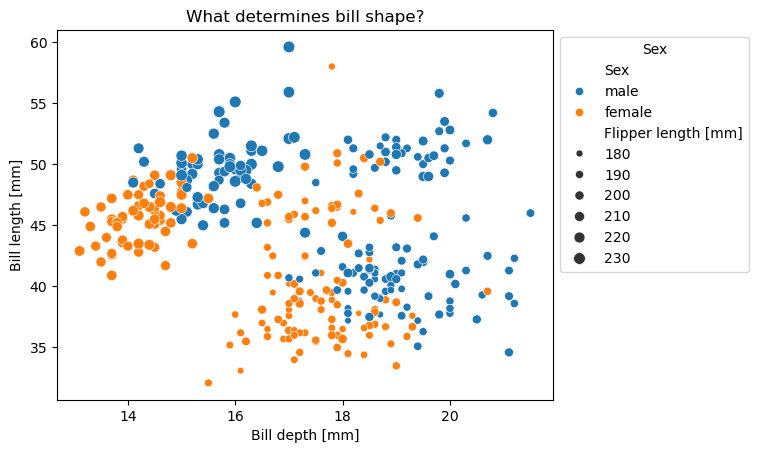

In [50]:
ax = sns.scatterplot(data = penguins, x = "bill_depth_mm", y = "bill_length_mm", hue = "sex", size = "flipper_length_mm")

plt.xlabel('Bill depth [mm]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill shape?')

# adding a legend!
color_label = "Sex" # change the label for the color legend here
size_label = "Flipper length [mm]" # change the label for the size legend here

legend = ax.get_legend()
legend.texts[0].set_text(color_label)
legend.texts[3].set_text(size_label)
sns.move_legend(ax, "upper left", bbox_to_anchor = (1, 1), title = "Sex")

# save figure
fig.savefig('bill_depth_bill_length_colorby_sex_sizeby_flipperlength.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Discuss the plot we just made! What can we learn from this? 

Feel free to play around with the color or sizes of the data points!

##### Q3: Bill length

Earlier we looked at the distribution of penguin bill lengths, and saw that there was a wide spread in values. Let's see if we can dig into that a bit more now.


**Question:** How well can we estimate the length of a penguin's bill if we have other information about the penguin?

**Stragey**: The basic plan is to create scatter plots of bill length against other properties and search for patterns or trends.

---







Text(0.5, 1.0, 'Distribution of Bill Length')

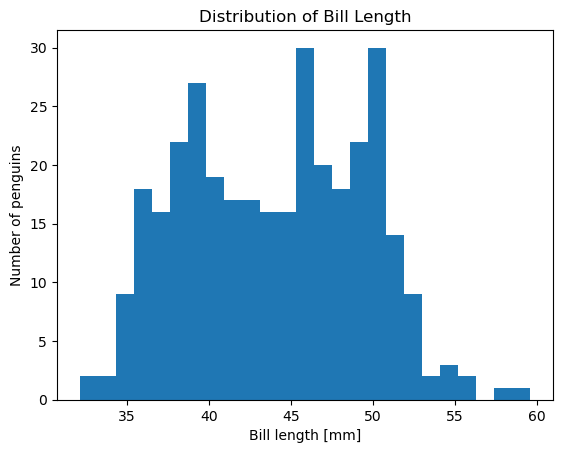

In [ ]:
plt.hist() # add your code to plot a histogram of bill length here

plt.xlabel('Bill length [mm]')
plt.ylabel('Number of penguins')
plt.title('Distribution of Bill Length')

As a first guess, we can check to see whether the body mass of the penguin is important. 

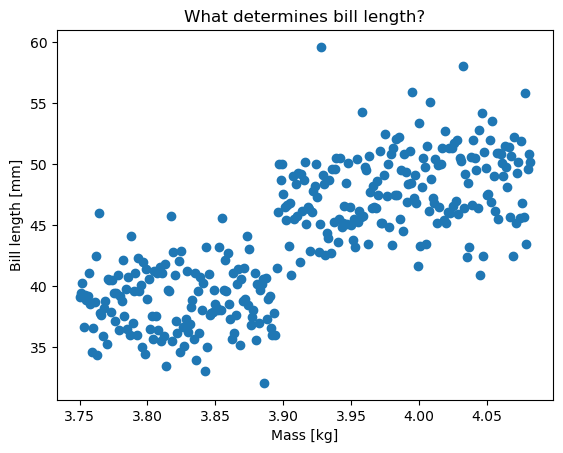

In [ ]:
plt.scatter() # add x and y values here

plt.xlabel('Mass [kg]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill length?')
plt.savefig('body_mass_bill_length.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  What do you notice? 

Is there a relationship between the length of the bill and the mass of the penguin? How much scatter in the data points do you see for a given mass? (In other words, if you know the mass of the penguin, how well do you know the bill length?)

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  What do you think could be contributing to the scatter here? (Which other properties in the dataset might be relevant?)

In the cell below, we can use the `color_property` parameter to check for any additional dependencies on which island the penguins are found on:

In [ ]:
sns.scatterplot() # add x, y, and hue values here
plt.xlabel('Mass [kg]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill length?')
plt.savefig('body_mass_bill_length_colorby_island.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  If we want to know the bill length of a penguin, to what extent is it useful to know which island the penguin lives on in addition to its mass?

In the cell below, we can use the `color_property` parameter to check for any additional dependencies on penguin species:

In [ ]:
sns.scatterplot() # add x, y, and hue values here
plt.xlabel('Mass [kg]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill length?')
plt.savefig('body_mass_bill_length_colorby_species.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80"> If we want to know the bill length of a penguin, to what extent is it useful to know its species in addition to its mass?

In the cell below, we can use the `color_property` parameter to check for any additional dependencies on the sex of the penguin:

In [ ]:
sns.scatterplot() # add x, y, and hue values here
plt.xlabel('Mass [kg]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill length?')

plt.savefig('body_mass_bill_length_colorby_sex.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  If we want to know the bill length of a penguin, to what extent is it useful to know its sex in addition to its mass?

In the cell below, we can use the `color_property` parameter to check for any additional dependencies on flipper length:

In [ ]:
sns.scatterplot() # add x, y, and hue values here
plt.xlabel('Mass [kg]')
plt.ylabel('Bill length [mm]')
plt.title('What determines bill length?')
plt.savefig('body_mass_bill_length_colorby_flipper_length.png')

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  If we want to know the bill length of a penguin, to what extent is it useful to know its flipper length in addition to its mass?

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  Take a minute and reflect on all the plots we just made! 

What information do we need to be able to roughly estimate (or guess) the length of a penguin's bill? How certain can we be? 

##### Q4-N [optional]

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190928390/129916976-rainbow-gradient-line-drawing-of-a-cartoon-exclamation-mark.jpg width="80">  Come up with a question (or multiple!) of your own to try to answer with the penguins dataset. 



What information do you need to answer it? What's your strategy? Try it out!

In [ ]:
# your code and plots here!

### Caveats to keep in mind

Any time we examine or explore data, it is extremely important to think critically about not only what the plots show us, but also what they are _not_ showing us. 

Interpreting data is a challenging undertaking, and an important aspect of this is understanding the limitations of your data and/or methodology.

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  What information about this dataset (or about the penguins) are we missing? How might the story be more complicated than we think based on these plots? 

<img src=https://previews.123rf.com/images/lineartestpilot/lineartestpilot1909/lineartestpilot190950393/130437321-rainbow-gradient-line-drawing-of-a-cartoon-question-mark.jpg width="80">  How could we improve upon our strategy of examining scatter plots to gain insights from our data?

---